In [4]:
!pip install arch
# -r /Users/marysia/Desktop/applied/ml_project/requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.4/930.4 kB 16.7 MB/s  0:00:00


In [50]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import glob
import os

In [51]:
df = pd.read_csv("/Users/marysia/Desktop/applied/ml_project/Data_clean/ETF clean/spy_clean.csv", index_col=0, parse_dates=True)
returns_df = df.drop(columns=['Open', 'High', 'Low']).pct_change().apply(lambda x: np.log(1 + x))

In [52]:
returns_df.head()

,Close,Volume
Date,,
2017-11-10,NaN,NaN
2017-11-09,0.000310,0.456946
2017-11-08,0.003634,-0.631433
2017-11-07,-0.001700,0.129315
2017-11-06,0.000696,-0.144315


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import warnings

# Ignorujemy ostrzeżenia o zbieżności modelu (częste przy małych oknach)
warnings.filterwarnings("ignore")

# 1. Wczytanie danych SPY
# Twoja struktura: Date,Open,High,Low,Close,Volume
spy_path = '/Users/marysia/Desktop/applied/ml_project/Data_clean/ETF clean/spy_clean.csv'
df_spy = pd.read_csv(spy_path, index_col='Date', parse_dates=True)

# Obliczamy log-zwroty na podstawie kolumny 'Close'
df_spy['Returns'] = np.log(df_spy['Close'] / df_spy['Close'].shift(1))
df_spy.dropna(inplace=True)

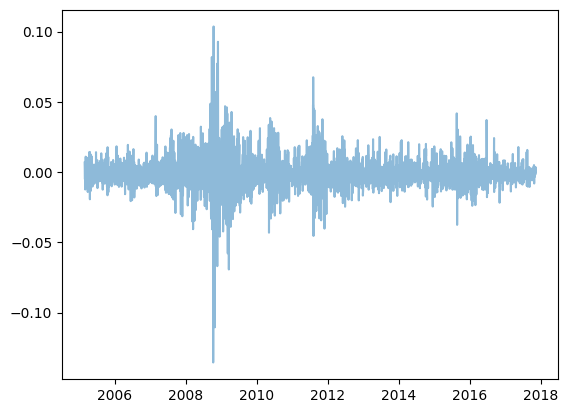

In [54]:
plt.plot(df_spy.index, df_spy['Returns'], alpha=0.5)


Text(0.5, 0, 'h')

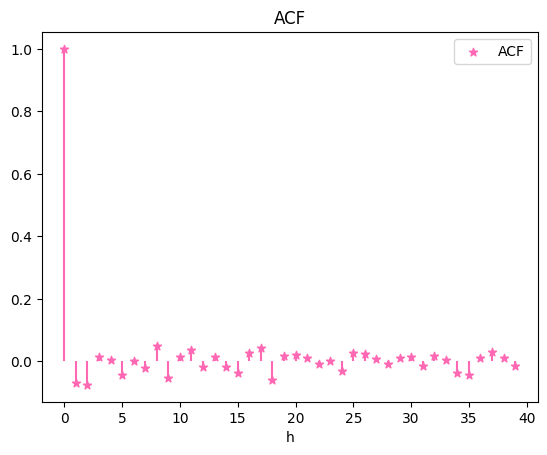

In [55]:
def sampleACVF(X, h):
    n = len(X)
    x_mean = np.mean(X)
    return 1/n*sum((X[i]-x_mean)*(X[i+abs(h)]-x_mean) for i in range(1,n-abs(h)))
def sampleACF(X, h):
    return sampleACVF(X, h)/sampleACVF(X, 0)

hs = np.arange(40)
acc = [sampleACF(np.array(df_spy['Returns']), h) for h in hs]
plt.vlines(x=hs, ymin=0, ymax=acc, color = 'hotpink')
plt.scatter(hs, acc, marker = '*', color = 'hotpink', label = 'ACF')
plt.title('ACF'); plt.legend()
plt.xlabel('h')

Text(0.5, 0, 'h')

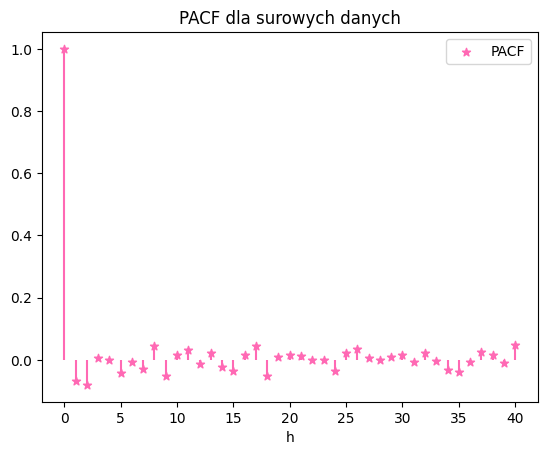

In [56]:
from statsmodels.tsa.stattools import pacf, adfuller, acf
pacf_, confint = pacf(np.array(df_spy['Returns']), nlags=40, method='ld', alpha=0.05)
# c1, c2 = np.array([p[0] for p in confint]), np.array([p[1] for p in confint])
# plt.fill_between(hs1, c1, c2, color = 'darkseagreen')
hs1 = np.arange(41)
plt.vlines(x=hs1, ymin=0, ymax=pacf_, color = 'hotpink')
plt.scatter(hs1, pacf_, marker = '*', color = 'hotpink', label = 'PACF')
plt.title('PACF dla surowych danych'); plt.legend()
plt.xlabel('h')

In [57]:
data = df_spy['Returns'].values

df = pd.DataFrame()
ps = []
qs = []
BIC = []
AIC = []
HQIC = []

max_p = 5
max_q = 5

for p in range(0, max_p):
    for q in range(0, max_q):
        model = ARIMA(data, order=(p, 0, q))
        model_fit = model.fit()
        ps.append(p)
        qs.append(q)
        AIC.append(model_fit.aic)
        BIC.append(model_fit.bic)
        HQIC.append(model_fit.hqic)

df['p']    = ps
df['q']    = qs
df['AIC']  = AIC
df['BIC']  = BIC
df['HQIC'] = HQIC

In [58]:
df.sort_values(by='AIC').head()

,p,q,AIC,BIC,HQIC
19,3,4,-20148.844842,-20093.888926,-20129.177488
10,2,0,-20144.408194,-20119.983342,-20135.667148
2,0,2,-20144.018859,-20119.594008,-20135.277813
15,3,0,-20142.470190,-20111.939126,-20131.543883
11,2,1,-20142.467854,-20111.936789,-20131.541546


In [59]:
df.sort_values(by='BIC').head()

,p,q,AIC,BIC,HQIC
10,2,0,-20144.408194,-20119.983342,-20135.667148
2,0,2,-20144.018859,-20119.594008,-20135.277813
6,1,1,-20136.391827,-20111.966976,-20127.650781
15,3,0,-20142.470190,-20111.939126,-20131.543883
11,2,1,-20142.467854,-20111.936789,-20131.541546


In [60]:
df.sort_values(by='HQIC').head()

,p,q,AIC,BIC,HQIC
10,2,0,-20144.408194,-20119.983342,-20135.667148
2,0,2,-20144.018859,-20119.594008,-20135.277813
15,3,0,-20142.470190,-20111.939126,-20131.543883
11,2,1,-20142.467854,-20111.936789,-20131.541546
3,0,3,-20142.136769,-20111.605705,-20131.210461


In [24]:
# 2. Test stacjonarności (ADF Test)
def check_stationarity(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    return result[1] < 0.05

print("--- Test Stacjonarności SPY ---")
is_stationary = check_stationarity(df_spy['Returns'])
print(f"Czy dane są stacjonarne? {is_stationary}\n")

--- Test Stacjonarności SPY ---
ADF Statistic: -14.1408
p-value: 0.0000
Czy dane są stacjonarne? True



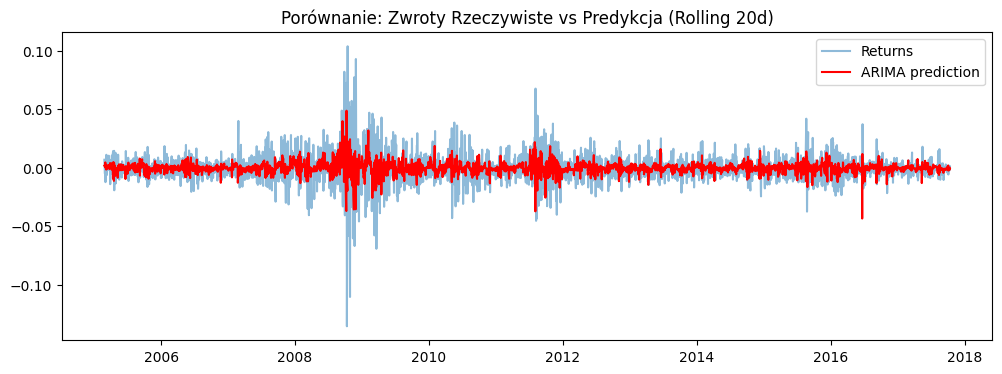

In [64]:
window = 20
results = []

for i in range(len(df_spy) - window):
    train_window = df_spy['Returns'].iloc[i:i+window]
    # ARIMA(1,0,1) - d=0 bo zwroty logarytmiczne są już stacjonarne
    model = ARIMA(train_window, order=(2, 0, 0)).fit()
    forecast = model.forecast(steps=1).values[0]
    results.append(forecast)

# Tworzymy DF z wynikami (pomijamy pierwsze 20 dni)
df_eval = df_spy.iloc[window:].copy()
df_eval['Pred_Return'] = results

# Wykres Porównawczy (Ostatnie 100 dni dla czytelności)
plt.figure(figsize=(12, 4))
plt.plot(df_eval['Returns'], label='Returns', alpha=0.5)
plt.plot(df_eval['Pred_Return'], label='ARIMA prediction', color='red')
plt.title('Porównanie: Zwroty Rzeczywiste vs Predykcja (Rolling 20d)')
plt.legend()
plt.show()

In [63]:
# Szybki test dla SPY
model_test = ARIMA(df_spy['Returns'].tail(100), order=(0, 0, 2)).fit()
print(model_test.summary())

                               SARIMAX Results                                
Dep. Variable:                Returns   No. Observations:                  100
Model:                 ARIMA(0, 0, 2)   Log Likelihood                 359.365
Date:                Mon, 20 Apr 2026   AIC                           -710.731
Time:                        08:44:53   BIC                           -700.310
Sample:                             0   HQIC                          -706.513
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0001      0.001     -0.199      0.842      -0.001       0.001
ma.L1         -0.1312      0.089     -1.471      0.141      -0.306       0.044
ma.L2          0.0625      0.106      0.589      0.5

In [62]:
from sklearn.metrics import accuracy_score

# Kierunek rzeczywisty vs przewidywany
df_eval['Actual_Dir'] = np.where(df_eval['Returns'] > 0, 1, 0)
df_eval['Pred_Dir'] = np.where(df_eval['Pred_Return'] > 0, 1, 0)

acc = accuracy_score(df_eval['Actual_Dir'], df_eval['Pred_Dir'])

print(f"Accuracy (Czy góra/dół?): {acc:.2%}")

Accuracy (Czy góra/dół?): 51.23%


/var/folders/7f/qnqr5kmj7z9b_f11s8sp00v80000gn/T/ipykernel_15533/923548008.py:7: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  garch = arch_model(train_window, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
/var/folders/7f/qnqr5kmj7z9b_f11s8sp00v80000gn/T/ipykernel_15533/923548008.py:7: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  garch = arch_model(train_window, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
/var/folders/7f/qnqr5kmj7z9b_f11s8sp00v80000gn/T/ipykernel_15533/923548008.py:7: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  garch = arch_model(train_window, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
/

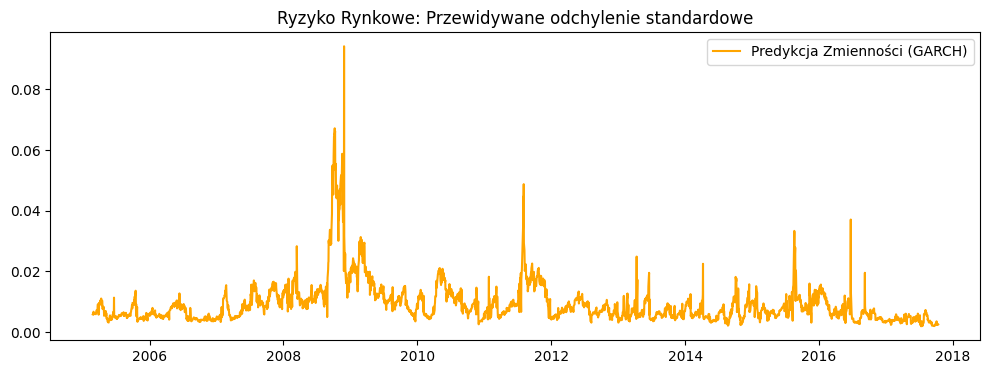

In [28]:
# GARCH trenujemy na tym samym oknie 20 dni
vols = []

for i in range(len(df_spy) - window):
    train_window = df_spy['Returns'].iloc[i:i+window]
    # rescale=False, żeby zachować jednostkę zwrotów
    garch = arch_model(train_window, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
    v_forecast = np.sqrt(garch.forecast(horizon=1).variance.values[-1][0])
    vols.append(v_forecast)

df_eval['Pred_Vol'] = vols

# Wykres zmienności
plt.figure(figsize=(12, 4))
plt.plot(df_eval['Pred_Vol'], color='orange', label='Predykcja Zmienności (GARCH)')
plt.title('Ryzyko Rynkowe: Przewidywane odchylenie standardowe')
plt.legend()
plt.show()

Trwa obliczanie prognoz (Rolling Window 20d)...


/var/folders/7f/qnqr5kmj7z9b_f11s8sp00v80000gn/T/ipykernel_15533/925076144.py:34: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  garch = arch_model(train_window, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
/var/folders/7f/qnqr5kmj7z9b_f11s8sp00v80000gn/T/ipykernel_15533/925076144.py:34: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  garch = arch_model(train_window, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
/var/folders/7f/qnqr5kmj7z9b_f11s8sp00v80000gn/T/ipykernel_15533/925076144.py:34: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  garch = arch_model(train_window, vol='Garch', p=1, q=1, rescale=False).fit(disp='off'

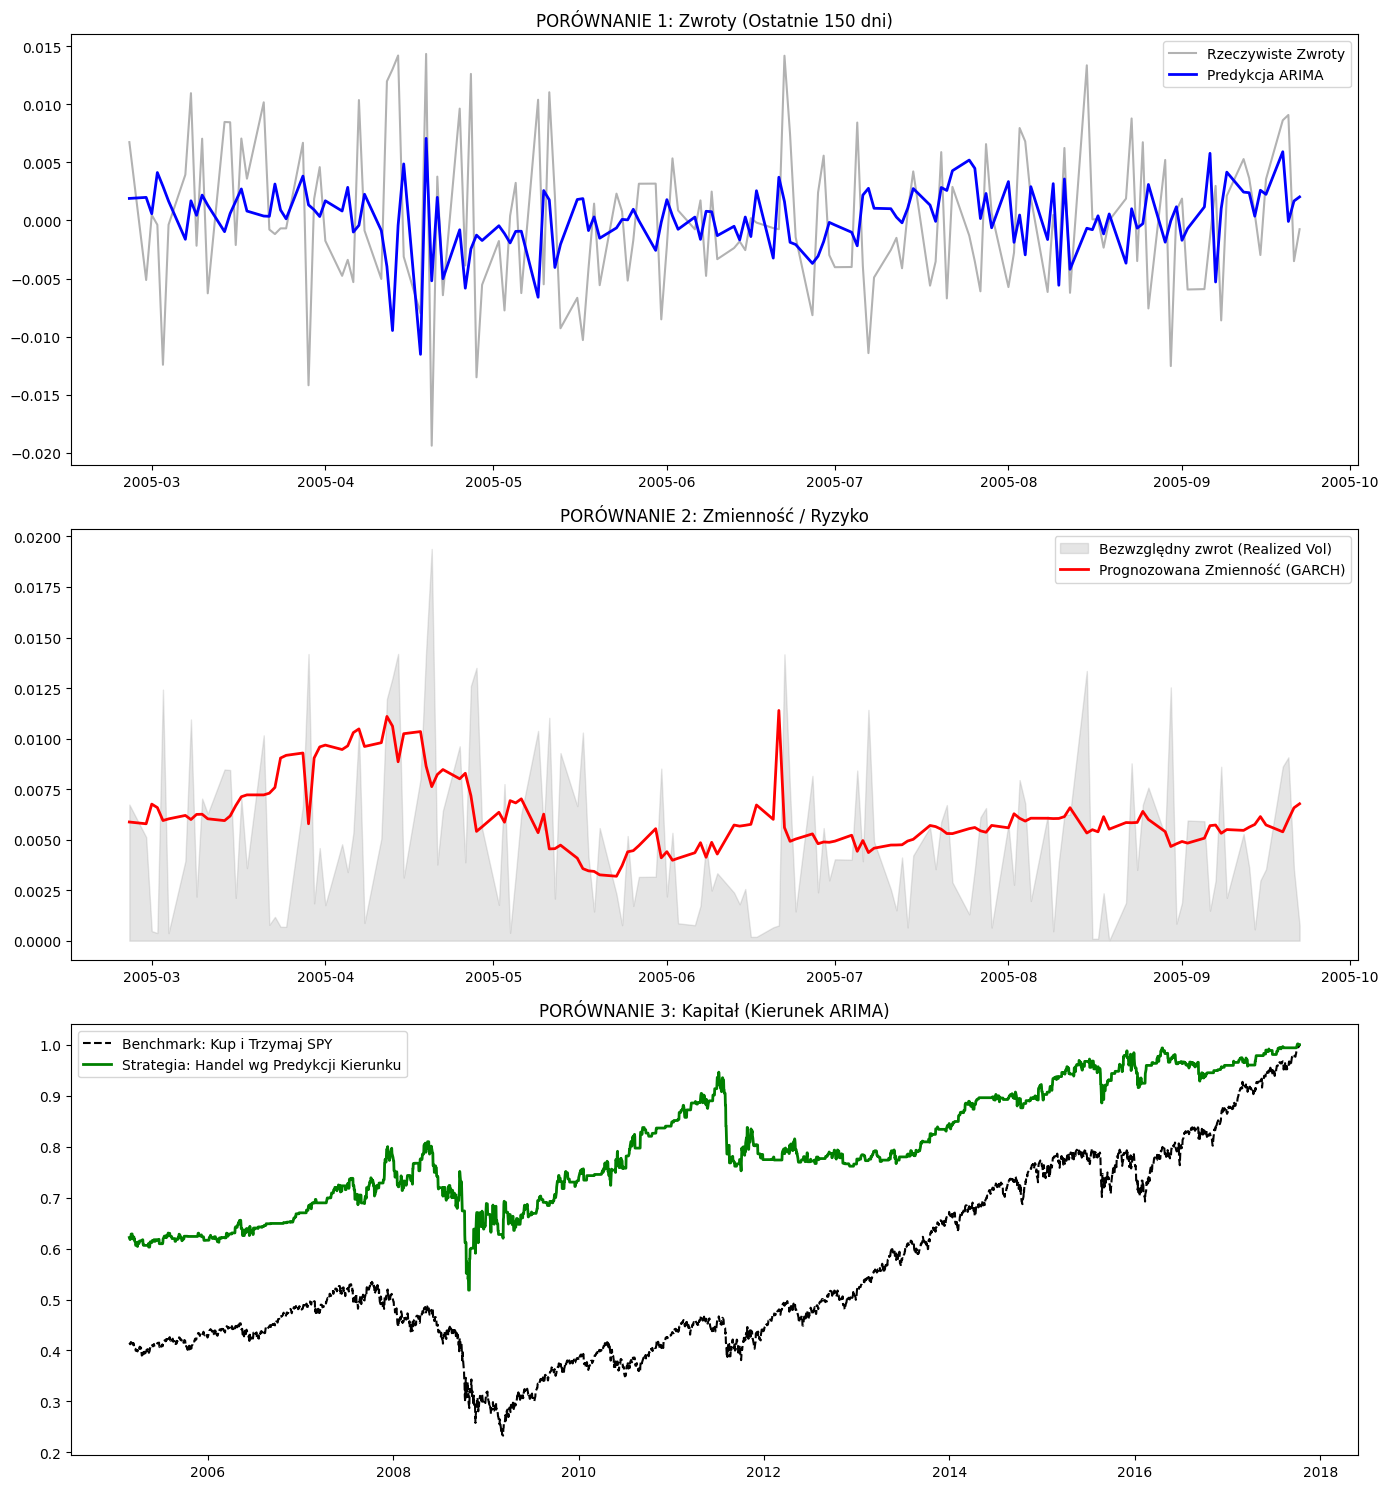

------------------------------
PODSUMOWANIE MODELU SP500:
Celność kierunku (Accuracy): 50.96%
------------------------------
Raport klasyfikacji:
              precision    recall  f1-score   support

      SPADEK       0.55      0.58      0.57      1812
      WZROST       0.45      0.42      0.43      1483

    accuracy                           0.51      3295
   macro avg       0.50      0.50      0.50      3295
weighted avg       0.51      0.51      0.51      3295



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from sklearn.metrics import accuracy_score, classification_report

# 1. Przygotowanie danych
spy = pd.read_csv(spy_path, index_col='Date', parse_dates=True)
spy['Returns'] = np.log(spy['Close'] / spy['Close'].shift(1))
spy.dropna(inplace=True)

# Ustawienia okna
window = 20
pred_returns = []
pred_vols = []

print("Trwa obliczanie prognoz (Rolling Window 20d)...")

for i in range(len(spy) - window):
    train_window = spy['Returns'].iloc[i:i+window]
    
    # --- MODEL 1: ARIMA (Returns) ---
    # Parametry: (1,0,1) - krótka pamięć rynkowa
    try:
        arima = ARIMA(train_window, order=(1, 0, 1)).fit()
        f_ret = arima.forecast(steps=1).values[0]
    except: f_ret = 0
        
    # --- MODEL 2: GARCH (Volatility) ---
    # Parametry: (1,1) - standardowy model ryzyka
    try:
        garch = arch_model(train_window, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
        f_vol = np.sqrt(garch.forecast(horizon=1).variance.values[-1][0])
    except: f_vol = spy['Returns'].std()

    pred_returns.append(f_ret)
    pred_vols.append(f_vol)

# Tworzymy DataFrame porównawczy
df_comp = spy.iloc[window:].copy()
df_comp['Pred_Return'] = pred_returns
df_comp['Pred_Vol'] = pred_vols
df_comp['Actual_Dir'] = (df_comp['Returns'] > 0).astype(int)
df_comp['Pred_Dir'] = (df_comp['Pred_Return'] > 0).astype(int)

# --- ANALIZA PORÓWNAWCZA ---

fig, axs = plt.subplots(3, 1, figsize=(14, 15))

# 1. Porównanie Zwrotów (Regresja)
axs[0].plot(df_comp['Returns'].tail(150), label='Rzeczywiste Zwroty', color='black', alpha=0.3)
axs[0].plot(df_comp['Pred_Return'].tail(150), label='Predykcja ARIMA', color='blue', linewidth=2)
axs[0].set_title('PORÓWNANIE 1: Zwroty (Ostatnie 150 dni)')
axs[0].legend()

# 2. Porównanie Zmienności (Ryzyko)
axs[1].plot(df_comp.index[-150:], df_comp['Returns'].tail(150), color='gray', alpha=0.2, label='Zwroty')
axs[1].plot(df_comp['Pred_Vol'].tail(150), label='Prognozowana Zmienność (GARCH)', color='red', linewidth=2)
axs[1].set_title('PORÓWNANIE 2: Zmienność / Ryzyko')
axs[1].legend()

# 3. Skumulowany Wynik (Efektywność Portfela)
spy_cum = (1 + (np.exp(df_comp['Returns']) - 1)).cumprod()
strat_cum = (1 + (df_comp['Pred_Dir'] * (np.exp(df_comp['Returns']) - 1))).cumprod()
axs[2].plot(spy_cum, label='Benchmark: Kup i Trzymaj SPY', color='black', linestyle='--')
axs[2].plot(strat_cum, label='Strategia: Handel wg Predykcji Kierunku', color='green', linewidth=2)
axs[2].set_title('PORÓWNANIE 3: Kapitał (Kierunek ARIMA)')
axs[2].legend()

plt.tight_layout()
plt.show()

# --- PODSUMOWANIE STATYSTYCZNE ---
acc = accuracy_score(df_comp['Actual_Dir'], df_comp['Pred_Dir'])
print("-" * 30)
print(f"PODSUMOWANIE MODELU SP500:")
print(f"Celność kierunku (Accuracy): {acc:.2%}")
print("-" * 30)
print("Raport klasyfikacji:")
print(classification_report(df_comp['Actual_Dir'], df_comp['Pred_Dir'], target_names=['SPADEK', 'WZROST']))

Generuję zaawansowane cechy (ARIMA 20d, GARCH 60d)...


/var/folders/7f/qnqr5kmj7z9b_f11s8sp00v80000gn/T/ipykernel_15533/1952757534.py:39: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  model_garch = arch_model(window_60, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
/var/folders/7f/qnqr5kmj7z9b_f11s8sp00v80000gn/T/ipykernel_15533/1952757534.py:39: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  model_garch = arch_model(window_60, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
/var/folders/7f/qnqr5kmj7z9b_f11s8sp00v80000gn/T/ipykernel_15533/1952757534.py:39: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  model_garch = arch_model(window_60, vol='Garch', p=1, q=1, rescale=False).fi


Gotowy Feature Matrix dla modeli ML:
             Close  Dist_From_MA200  ARIMA_20d_Pred  GARCH_60d_Vol
Date                                                              
2005-03-03  105.61         0.003709        0.002935       0.007104
2005-03-02  105.57         0.003531        0.004118       0.007895
2005-03-01  105.62         0.004238        0.000575       0.007630
2005-02-28  105.08        -0.000650        0.001980       0.007439
2005-02-25  105.79         0.006328        0.001891       0.007377


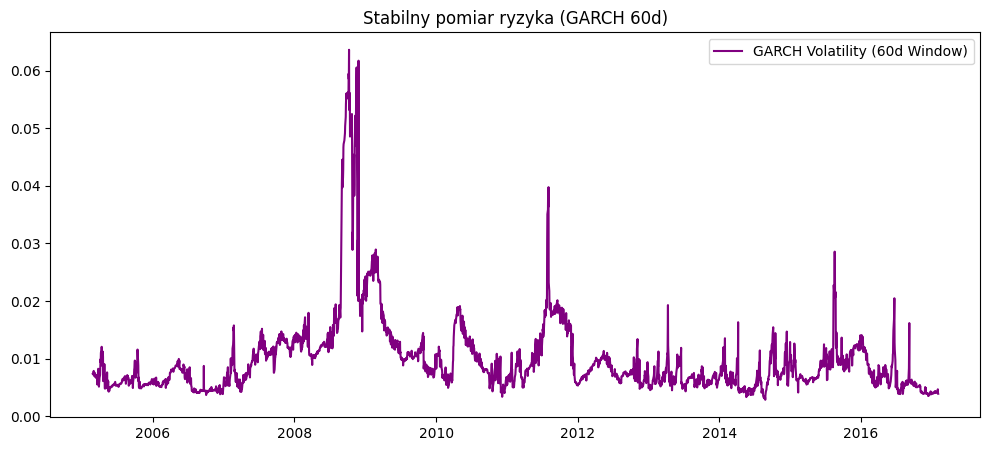

In [36]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import warnings

warnings.filterwarnings("ignore")

# 1. Przygotowanie danych bazowych
spy = pd.read_csv(spy_path, index_col='Date', parse_dates=True)
spy['Returns'] = np.log(spy['Close'] / spy['Close'].shift(1))

# 2. Wskaźniki Długoterminowe (Obliczane na całym szeregu - szybkie)
# Średnia krocząca 200 dni (Trend długoterminowy)
spy['MA200_Trend'] = spy['Close'].rolling(window=200).mean()
spy['Dist_From_MA200'] = (spy['Close'] - spy['MA200_Trend']) / spy['MA200_Trend']

# 3. Pętla Krocząca dla ARIMA (20d) i GARCH (60d)
# Zaczynamy od 200, żeby MA200 było już gotowe
start_idx = 200
arima_preds = []
garch_vols = []
dates = []

print("Generuję zaawansowane cechy (ARIMA 20d, GARCH 60d)...")

for i in range(start_idx, len(spy)):
    # --- KRÓTKIE OKNO (20d) dla ARIMA ---
    window_20 = spy['Returns'].iloc[i-20:i]
    try:
        model_arima = ARIMA(window_20, order=(1, 0, 1)).fit()
        pred_ret = model_arima.forecast(steps=1).values[0]
    except: pred_ret = 0
    
    # --- DŁUŻSZE OKNO (60d) dla GARCH ---
    # Zmienność potrzebuje więcej danych, by "zauważyć" trend strachu
    window_60 = spy['Returns'].iloc[i-60:i]
    try:
        model_garch = arch_model(window_60, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
        pred_vol = np.sqrt(model_garch.forecast(horizon=1).variance.values[-1][0])
    except: pred_vol = spy['Returns'].iloc[:i].std()

    arima_preds.append(pred_ret)
    garch_vols.append(pred_vol)
    dates.append(spy.index[i])

# 4. Łączenie wszystkiego w jedną tabelę (Feature Matrix)
df_features = spy.loc[dates].copy()
df_features['ARIMA_20d_Pred'] = arima_preds
df_features['GARCH_60d_Vol'] = garch_vols

# Czyścimy NaN (z MA200)
df_features.dropna(inplace=True)

# 5. Podsumowanie i podgląd
print("\nGotowy Feature Matrix dla modeli ML:")
print(df_features[['Close', 'Dist_From_MA200', 'ARIMA_20d_Pred', 'GARCH_60d_Vol']].tail())

# Wizualizacja dla raportu: Porównanie zmienności 20d vs 60d (opcjonalnie)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(df_features['GARCH_60d_Vol'], color='purple', label='GARCH Volatility (60d Window)')
plt.title('Stabilny pomiar ryzyka (GARCH 60d)')
plt.legend()
plt.show()

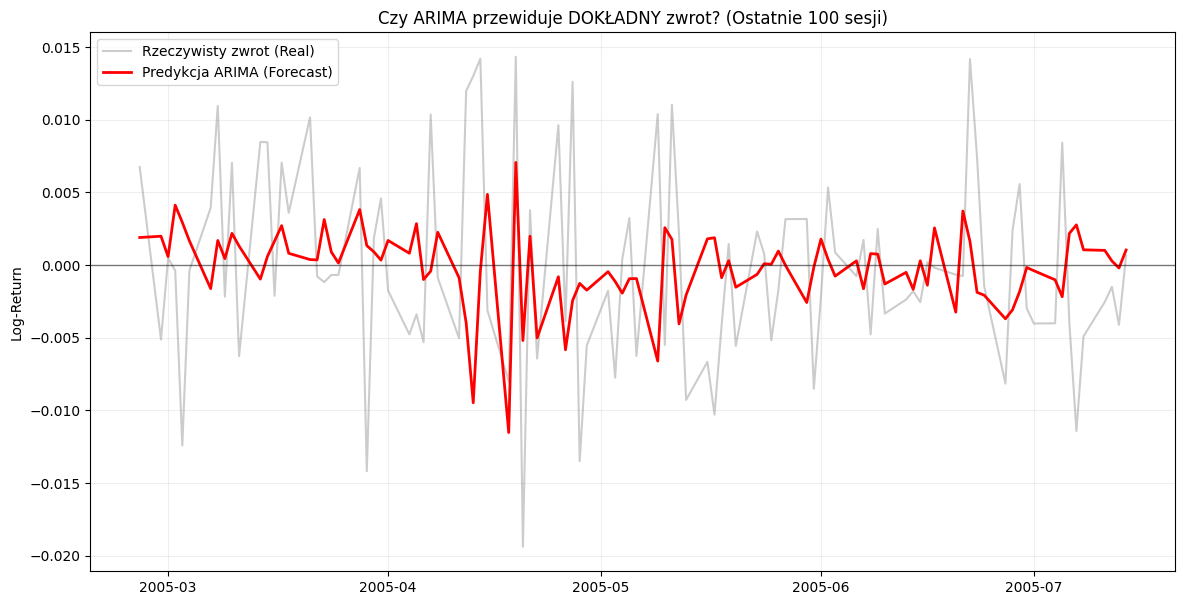

In [37]:
import matplotlib.pyplot as plt

# Zakładamy, że masz już df_features z kolumnami 'Returns' i 'ARIMA_20d_Pred'

plt.figure(figsize=(14, 7))

# 1. Rzeczywiste zwroty (szare, tło)
plt.plot(df_features['Returns'].tail(100), label='Rzeczywisty zwrot (Real)', color='gray', alpha=0.4)

# 2. Predykcja modelu (czerwona, wyraźna)
plt.plot(df_features['ARIMA_20d_Pred'].tail(100), label='Predykcja ARIMA (Forecast)', color='red', lw=2)

plt.axhline(0, color='black', lw=1, alpha=0.5)
plt.title('Czy ARIMA przewiduje DOKŁADNY zwrot? (Ostatnie 100 sesji)')
plt.ylabel('Log-Return')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

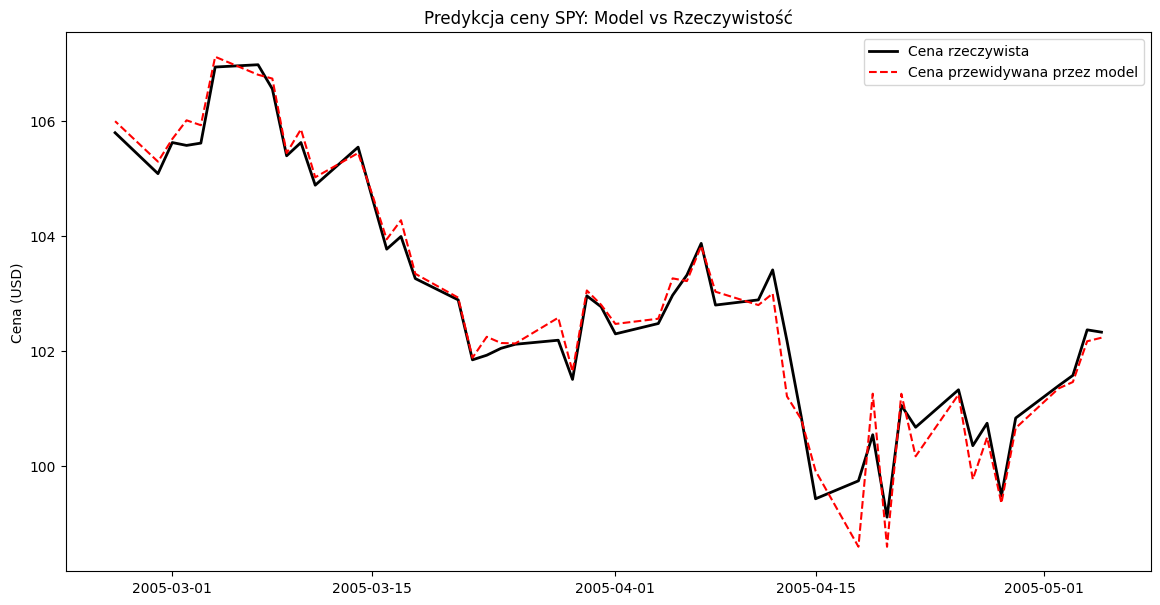

In [ ]:
# Obliczamy przewidywaną cenę
df_features['Pred_Price'] = df_features['Close']* np.exp(df_features['ARIMA_20d_Pred'])#.shift(1) 

plt.figure(figsize=(14, 7))
plt.plot(df_features['Close'].tail(50), label='Cena rzeczywista', color='black', lw=2)
plt.plot(df_features['Pred_Price'].tail(50), label='Cena przewidywana przez model', color='red', linestyle='--')

plt.title('Predykcja ceny SPY: Model vs Rzeczywistość')
plt.ylabel('Cena (USD)')
plt.legend()
plt.show()

## next step

In [40]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report

# 1. Tworzymy Target: Czy cena wzrośnie JUTRO?
# Przesuwamy zwroty o -1, aby model na podstawie dzisiejszych danych przewidywał jutro
df_features['Target'] = (df_features['Returns'].shift(-1) > 0).astype(int)

# 2. Dodajemy dodatkowe cechy techniczne (paliwo dla ML)
df_features['Vol_Change'] = df_features['Volume'].pct_change()
df_features['Intraday_Range'] = (df_features['High'] - df_features['Low']) / df_features['Open']

# Czyścimy ostatni wiersz (bo Target dla niego nie istnieje)
df_ml = df_features.dropna()

# 3. Wybór cech do modelu
# Łączymy wskaźniki statystyczne (ARIMA/GARCH) z technicznymi
features = [
    'ARIMA_20d_Pred', 'GARCH_60d_Vol', 'Dist_From_MA200', 
    'Vol_Change', 'Intraday_Range', 'Returns'
]

# 4. Podział na zbiór treningowy i testowy (chronologiczny!)
split = int(len(df_ml) * 0.8)
X_train, y_train = df_ml[features].iloc[:split], df_ml['Target'].iloc[:split]
X_test, y_test = df_ml[features].iloc[split:], df_ml['Target'].iloc[split:]

In [41]:
# Konfiguracja modelu
params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.02,
    'num_leaves': 15,
    'max_depth': 4,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'seed': 42,
    'verbose': -1
}

# Trening
d_train = lgb.Dataset(X_train, label=y_train)
model_lgb = lgb.train(params, d_train, num_boost_round=200)

# Predykcja (prawdopodobieństwo)
y_prob = model_lgb.predict(X_test)
# Klasyfikacja (jeśli prawd. > 0.5, to przewidujemy wzrost)
y_pred = (y_prob > 0.5).astype(int)

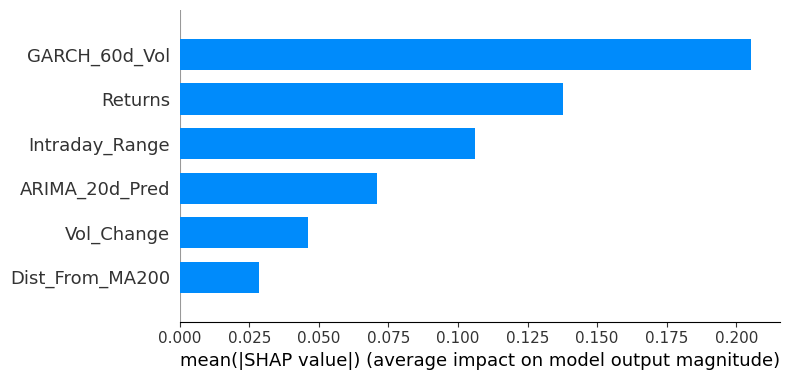

In [42]:
import shap

# Obliczamy wartości SHAP
explainer = shap.TreeExplainer(model_lgb)
shap_values = explainer.shap_values(X_test)

# Wizualizacja ważności cech
shap.summary_plot(shap_values, X_test, plot_type="bar")

## wybrór spółek

In [43]:
import os
import pandas as pd
import numpy as np
import lightgbm as lgb

# Zakładamy, że model_lgb jest już wytrenowany na SPY (z poprzedniego kroku)
# Ścieżka do Twoich danych
stocks_path = '/Users/marysia/Desktop/applied/ml_project/Data_clean/Stocks clean'
stock_files = [f for f in os.listdir(stocks_path) if f.endswith('.csv')]

ranking_results = []

print("Skanowanie 27 spółek za pomocą modelu LightGBM...")

for file in stock_files:
    # 1. Wczytanie danych spółki
    df = pd.read_csv(os.path.join(stocks_path, file), index_col='Date', parse_dates=True)
    symbol = file.replace('_clean.csv', '').upper()
    
    if len(df) < 252: continue # Pomijamy zbyt krótkie historie
    
    # 2. Obliczanie Log-Returns
    df['Returns'] = np.log(df['Close'] / df['Close'].shift(1))
    
    # 3. Generowanie Cech (tych samych co dla SPY)
    # MA 200 i Dystans
    df['MA200_Trend'] = df['Close'].rolling(window=200).mean()
    df['Dist_From_MA200'] = (df['Close'] - df['MA200_Trend']) / df['MA200_Trend']
    
    # Inne cechy techniczne
    df['Vol_Change'] = df['Volume'].pct_change()
    df['Intraday_Range'] = (df['High'] - df['Low']) / df['Open']
    
    # ARIMA (20d) i GARCH (60d) - tylko dla ostatniego dostępnego dnia
    # Robimy to tylko raz dla najświeższych danych, żeby oszczędzić czas
    try:
        window_20 = df['Returns'].iloc[-20:]
        model_arima = ARIMA(window_20, order=(1, 0, 1)).fit()
        last_arima = model_arima.forecast(steps=1).values[0]
        
        window_60 = df['Returns'].iloc[-60:]
        model_garch = arch_model(window_60, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
        last_garch = np.sqrt(model_garch.forecast(horizon=1).variance.values[-1][0])
        
        # 4. Przygotowanie wektora cech dla LightGBM
        # Muszą być w tej samej kolejności co w treningu!
        current_features = pd.DataFrame([{
            'ARIMA_20d_Pred': last_arima,
            'GARCH_60d_Vol': last_garch,
            'Dist_From_MA200': df['Dist_From_MA200'].iloc[-1],
            'Vol_Change': df['Vol_Change'].iloc[-1],
            'Intraday_Range': df['Intraday_Range'].iloc[-1],
            'Returns': df['Returns'].iloc[-1]
        }])
        
        # 5. Predykcja prawdopodobieństwa wzrostu
        prob_up = model_lgb.predict(current_features)[0]
        
        ranking_results.append({
            'Ticker': symbol,
            'Prob_Growth': prob_up,
            'Current_Vol': last_garch,
            'Trend': 'Bullish' if df['Dist_From_MA200'].iloc[-1] > 0 else 'Bearish'
        })
    except:
        continue

# 6. Prezentacja Top 3 Najlepszych Wyborów
ranking_df = pd.DataFrame(ranking_results).sort_values(by='Prob_Growth', ascending=False)

print("\n" + "="*40)
print("TOP 3 REKOMENDACJE (NAJWIĘKSZA SZANSA WZROSTU)")
print("="*40)
print(ranking_df.head(3).to_string(index=False))

print("\n" + "="*40)
print("UNIKAJ (NAJWIĘKSZA SZANSA SPADKU)")
print("="*40)
print(ranking_df.tail(3).to_string(index=False))

Skanowanie 27 spółek za pomocą modelu LightGBM...

TOP 3 REKOMENDACJE (NAJWIĘKSZA SZANSA WZROSTU)
Ticker  Prob_Growth  Current_Vol   Trend
  ORCL     0.756707     0.036383 Bearish
 GOOGL     0.747117     0.052092 Bearish
  NVDA     0.719865     0.046927 Bearish

UNIKAJ (NAJWIĘKSZA SZANSA SPADKU)
Ticker  Prob_Growth  Current_Vol   Trend
    BA     0.425634     0.033472 Bullish
   CRM     0.416984     0.026152 Bearish
   GLD     0.319407     0.006282 Bearish


## dodawanie wyboru sektora - jeszcze nie gotowe

In [47]:
import os
import pandas as pd
import numpy as np

# 1. Mapowanie akcji do sektorów (przykład - dostosuj do swojej listy 27 akcji)
sector_map = {
    # XLK - Technology
    'AAPL': 'XLK', 'MSFT': 'XLK', 'NVDA': 'XLK', 'AVGO': 'XLK', 'ORCL': 'XLK', 'ADBE': 'XLK',
    # XLV - Healthcare
    'LLY': 'XLV', 'JNJ': 'XLV', 'UNH': 'XLV', 'ABBV': 'XLV', 'MRK': 'XLV',
    # XLF - Financials
    'JPM': 'XLF', 'BAC': 'XLF', 'WFC': 'XLF', 'GS': 'XLF', 'MS': 'XLF',
    # XLC - Communication Services
    'GOOGL': 'XLC', 'META': 'XLC', 'NFLX': 'XLC', 'DIS': 'XLC',
    # XLY - Consumer Discretionary
    'AMZN': 'XLY', 'TSLA': 'XLY', 'HD': 'XLY', 'NKE': 'XLY',
    # XLP - Consumer Staples
    'PG': 'XLP', 'KO': 'XLP', 'PEP': 'XLP'
}

# 2. Skanowanie Sektorów (ETF clean)
etf_path = '/Users/marysia/Desktop/applied/ml_project/Data_clean/ETF clean'
etf_files = [f for f in os.listdir(etf_path) if f.endswith('.csv') and f != 'spy_clean.csv']

sector_ranking = []

print("Analiza Sektorowa (Top-Down)...")

for file in etf_files:
    df_etf = pd.read_csv(os.path.join(etf_path, file), index_col='Date', parse_dates=True)
    symbol = file.replace('_clean.csv', '').upper()
    
    # Obliczamy te same cechy co dla SPY
    df_etf['Returns'] = np.log(df_etf['Close'] / df_etf['Close'].shift(1))
    
    # Korzystamy z uproszczonego scoringu (Trend + Momentum + Volatility)
    # Możesz tu też użyć wytrenowanego wcześniej model_lgb
    last_ret = df_etf['Returns'].iloc[-20:].mean() # Średni zwrot 20d
    last_vol = df_etf['Returns'].iloc[-20:].std()  # Zmienność 20d
    sharpe_ratio = last_ret / last_vol if last_vol != 0 else 0
    
    sector_ranking.append({
        'Sector': symbol,
        'Score': sharpe_ratio,
        'Condition': 'Bullish' if df_etf['Close'].iloc[-1] > df_etf['Close'].rolling(200).mean().iloc[-1] else 'Bearish'
    })

# Ranking sektorów
df_sectors = pd.DataFrame(sector_ranking).sort_values(by='Score', ascending=False)
best_sector = df_sectors.iloc[0]['Sector']

print("\nRANKING SEKTORÓW:")
print(df_sectors.to_string(index=False))
print(f"\nNAJSILNIEJSZY SEKTOR OBECNIE: {best_sector}")

Analiza Sektorowa (Top-Down)...

RANKING SEKTORÓW:
Sector     Score Condition
   XLF  0.380878   Bullish
   IWM  0.329071   Bearish
   VTI  0.325019   Bearish
   DIA  0.316408   Bullish
   XLK  0.236404   Bearish
   XLV  0.191970   Bearish
   XLE  0.180515   Bearish
    VT  0.164528   Bullish
   QQQ -0.171986   Bearish

NAJSILNIEJSZY SEKTOR OBECNIE: XLF


In [48]:
# Filtrowanie wyników z poprzedniego kroku (ranking_df)
top_sectors = df_sectors.head(3)['Sector'].tolist()

# Dodajemy informację o sektorze do rankingu akcji
ranking_df['Sector'] = ranking_df['Ticker'].map(sector_map)

# Wybieramy tylko te akcje, które należą do silnych sektorów
filtered_ranking = ranking_df[ranking_df['Sector'].isin(top_sectors)]

print("\n" + "="*45)
print(f"TOP 3 AKCJE Z NAJSILNIEJSZYCH SEKTORÓW ({', '.join(top_sectors)})")
print("="*45)
print(filtered_ranking.head(3).to_string(index=False))


TOP 3 AKCJE Z NAJSILNIEJSZYCH SEKTORÓW (XLF, IWM, VTI)
Ticker  Prob_Growth  Current_Vol   Trend Sector
    MS     0.601249     0.018731 Bullish    XLF
   WFC     0.570019     0.015940 Bearish    XLF
    GS     0.546850     0.031263 Bearish    XLF


In [49]:
import os
import pandas as pd
import numpy as np

# Ścieżki

# 1. ANALIZA SEKTORÓW (Ranking)
sector_data = []
for ticker in set(sector_map.values()):
    file_path = os.path.join(etf_path, f"{ticker.lower()}_clean.csv")
    if os.path.exists(file_path):
        df_etf = pd.read_csv(file_path, index_col='Date', parse_dates=True)
        # Obliczamy momentum (zwrot 20d) i zmienność (GARCH-like std)
        returns = np.log(df_etf['Close'] / df_etf['Close'].shift(1))
        score = returns.tail(20).mean() / returns.tail(20).std() # Sharpe-like score
        
        sector_data.append({
            'Sector': ticker,
            'Sector_Score': score,
            'Sector_Trend': 'UP' if df_etf['Close'].iloc[-1] > df_etf['Close'].rolling(200).mean().iloc[-1] else 'DOWN'
        })

df_sector_rank = pd.DataFrame(sector_data).sort_values(by='Sector_Score', ascending=False)

# 2. INTEGRACJA Z TWOIM RANKINGIEM AKCJI (ranking_df z poprzedniego kroku)
# Dodajemy kolumnę sektora do Twoich wyników LightGBM
ranking_df['Sector'] = ranking_df['Ticker'].map(sector_map)

# Łączymy wyniki akcji z wynikami ich sektorów
final_decision_df = ranking_df.merge(df_sector_rank, on='Sector', how='left')

# 3. FINALNY FILTR (The "Gold Standard" Selection)
# Kryteria: 
# - Wysokie prawdopodobieństwo wzrostu z LightGBM (Prob_Growth)
# - Sektor musi być w trendzie wzrostowym (Sector_Trend == UP)
# - Sektor musi mieć dodatni wynik (Sector_Score > 0)

top_picks = final_decision_df[
    (final_decision_df['Sector_Trend'] == 'UP') & 
    (final_decision_df['Sector_Score'] > 0)
].sort_values(by='Prob_Growth', ascending=False)

# --- WIZUALIZACJA WYNIKÓW ---
print("\n" + "="*60)
print("             RAPORT DECYZYJNY: SEKTOR + AKCJA")
print("="*60)
if not top_picks.empty:
    print(top_picks[['Ticker', 'Sector', 'Prob_Growth', 'Sector_Score', 'Trend']].head(5).to_string(index=False))
else:
    print("BRAK SILNYCH SYGNAŁÓW: Rynek w trendzie spadkowym lub wysokie ryzyko.")
print("="*60)


             RAPORT DECYZYJNY: SEKTOR + AKCJA
Ticker Sector  Prob_Growth  Sector_Score   Trend
    MS    XLF     0.601249      0.380878 Bullish
   WFC    XLF     0.570019      0.380878 Bearish
    GS    XLF     0.546850      0.380878 Bearish
   JPM    XLF     0.540091      0.380878 Bullish
   BAC    XLF     0.499558      0.380878 Bullish
